# Complex $\theta$ test
The ABC theorem holds even when the complex-scaling rotation angle $\theta$ is extended into the complex plane. Here, we see if EC performs better when trained on resonance wavefunctions at complex $\theta$.

#### NOTE: the following explanation is on the right track, but it's hand-wavey.
#### TODO: clean this explanation up.

Theoretically, the ABC theorem holds forall $\phi$ in the subset 
$$
\{\phi \in \mathbb{C} \;|\; \Re(\phi)\in (\phi_\text{min}, \phi_\text{max})\subset\mathbb{R} \text{ and } \Im(\phi)\in (-\infty, \infty)\}.
$$
Due to finite volume effects, $\Im(\phi)_\text{eff}\in S\subset \mathbb{R}$. This is explained as follows: in the complex-scaled resonance wavefunction, there will be a factor $\exp(\alpha e^{\theta_I})$). This factor is highly sensitive to the value of $\theta_I = \Im(\theta)$, and it stretches / shrinks the radial ray considerably. We have to discretize the radial ray, so too much shrinking / stretching can lead to UV or IR effects. Thus, there's only a small effective window in which $\theta_I$ can vary.

# System 1: $V(r) = 2.0\exp\left[-\left(\frac{r-3}{1.5}\right)^2\right]$, narrow $s$-wave resonance.
- Supports an $s$-wave resonance at $E=1.606-i0.047$.
    - $\phi_\text{min}=\text{arg}(E) / 2 \approx 0.0146$.
    - $V(r)$ is a Gaussian, so $\phi_\text{max}=\pi/4\approx0.785$
- $\phi_\text{min} \le \phi < \phi_\text{max} = 0.0146 \le \phi < 0.785$.
- By $r=10$, $V(r=10)\propto 10^{-13} \approx 0$.

Due to finite volume effects, the good region of $\phi$ might vary from its theoretical value. This is a very narrow resonance. This gives
EC a much larger region to train over and a much smaller gap to extrapolate across for back-rotation.

In [1]:
from src.dvr import DVR
from src.utils.utils import *
from src.utils.sweep_utils import *
from src.ec import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define system parameters
n_best = 256                      # number of DVR grid points
phi_best = np.pi / 24             # rotation angle (in good sector)
real_res = 1.60569 - 1j*0.046588      # expected value of resonance
real_rr = 0.773962 + 1j*0.19941168
L_best = 50.0                     # system size

gauss_s = lambda r: 2.0 * np.exp(-((r-3.0)/1.5)**2) # potential

In [3]:
dvr_system = DVR(n_best, L_best, phi_best, potential=gauss_s, l=0)

### Plot of the good region of $\phi$ for system 1

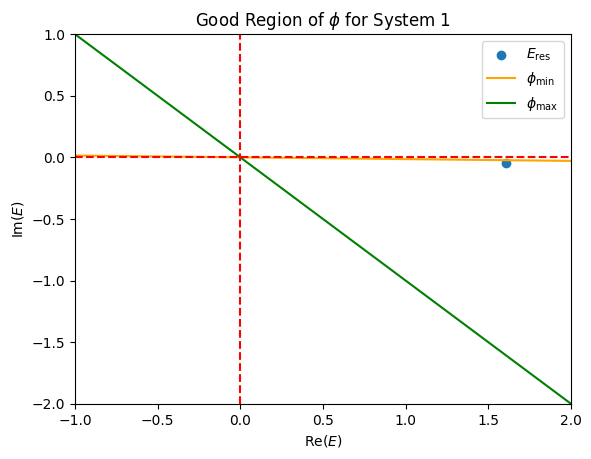

In [4]:
fig, ax = plt.subplots()
ax.set_xlim([-1.0, 2.0])
ax.set_ylim([-2.0, 1.0])
ax.scatter(np.real(real_res), np.imag(real_res), label=r'$E_\text{res}$')
ax.set_xlabel(r"Re$(E)$")
ax.set_ylabel(r"Im$(E)$")
ax.set_title(r"Good Region of $\phi$ for System 1")
plt.axline((0,0), (1.0, np.angle(real_res)/2), color='orange', label=r'$\phi_\text{min}$')
plt.axline((0,0), (1, -np.tan(np.pi/4)), color='green', label=r'$\phi_\text{max}$')
plt.axvline(0, linestyle='--', color='red')
plt.axhline(0, linestyle='--', color='red')
plt.legend()
plt.show()

### $E(L)$ and $(r_\theta^2)(L)$ at fixed $\phi$.
We plot $E$ and $(r_\theta^2)$ across several $L$ at a fixed $\phi$ in the "good" complex-scaling window ($\phi= \pi/24\approx0.13$). Both observables converge to a constant value as $L$ increases, consistent with standard results in finite-volume physics. We note that the observables tend to oscillate around a central value, with the envelope of the oscillations damping as $L$ increases.

... Explanation of oscillations ... 

Lastly, we note that the behavior of $E(L)$ and $(r_\phi^2)(L)$ do depend on $\phi$. We analyze this relationship shortly.

In [5]:
# compute <r^2> as L varies
mesh_width = 0.2
observables = {
    "energy": obs_energy,
    "rr": obs_rr
}
Ls = np.linspace(20.0, 75.0, 150)
results = scan_vs_L(
    phi_best,
    real_res,
    Ls, 
    mesh_width,
    observables,
    resonance_potential=gauss_s,
    resonance_l=0
)
energies = results["energy"]
rrs = results["rr"]

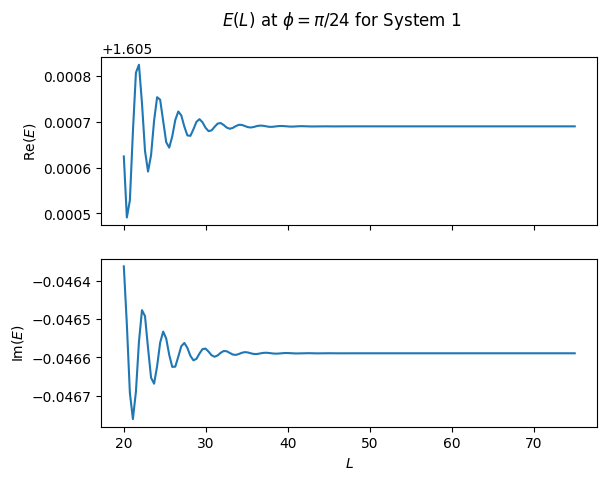

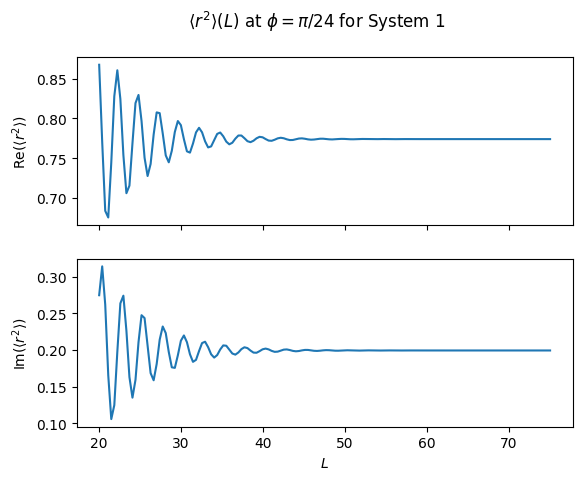

In [6]:
# plot E(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(energies))
ax2.plot(Ls, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(r"$E(L)$ at $\phi=\pi/24$ for System 1")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(rrs))
ax2.plot(Ls, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(r"$\langle r^2\rangle(L)$ at $\phi=\pi/24$ for System 1")
plt.show()

### $E(\phi)$ and $(r^2)(\theta)$ at fixed $L$
We plot $E$ and $(r^2)$ across several $\phi$ in the "good" complex-scaling window, at a fixed, well-converged box size ($L=50$). Both observables are nearly $\phi$-dependent over a central subset of this window, consistent with the ABC theorem. But, they degrade near the edges, before the theoretical minimum and maximum are reached. 

Near $\phi_\text{min}$ approaches $\phi_\text{min}$, coupling with the finite-volume continuum states can contaminate the data. After complex scaling, $V(r)\propto \exp(-r^2\cos(2\theta))$. $As $\phi$ approaches $\phi_\text{max}$, the radial extent instability can contaminate the data before the theoretical maximum is actually reached.

In [7]:
# compute E and <r^2> as phi varies
# the ABC theorem says that this should be const.
phi_scan = 50
phi_lo, phi_hi = get_phi_bounds(real_res)
phis = np.linspace(phi_lo, phi_hi, phi_scan)

results = scan_vs_phi(
    dvr_system,
    real_res,
    phis,
    observables
)
energies, rrs = results["energy"], results["rr"]

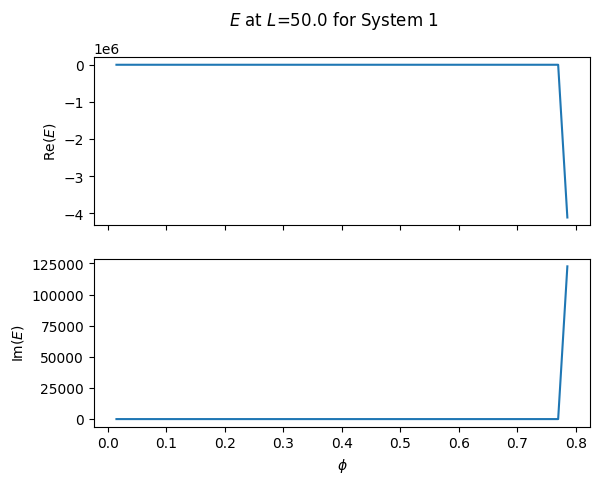

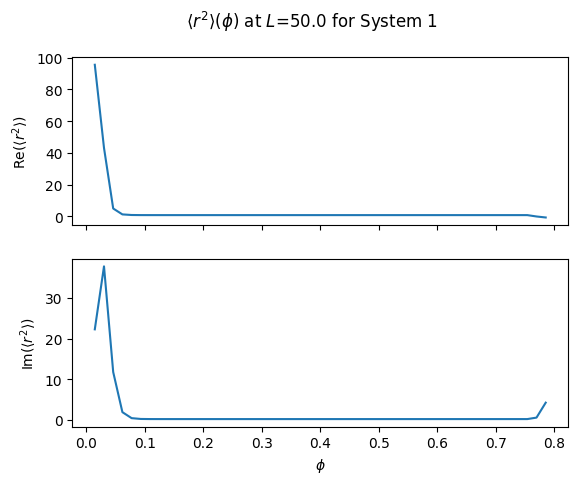

In [8]:
# plot <E>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(energies))
ax2.plot(phis, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$E$ at $L$=50.0 for System 1")
plt.show()

# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(rrs))
ax2.plot(phis, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$\langle r^2\rangle(\phi)$ at $L$=50.0 for System 1")
plt.show()

### Extend $\phi$ to the complex plane and analyze plateau regions using DVR.
Here, we use DVR to analyze how $E(\phi)$, $(r^2)(\phi)$, and $u_\phi(r)$ vary in complex $\theta$.

In [9]:
# phi region that looks good is phi = (0.2, 0.55)
phi_lo_real, phi_hi_real, phi_real_scan = 0.15, 0.55, 25
# construct imaginary range
phi_lo_imag, phi_hi_imag, phi_imag_scan = -.65, .4, 25

# NOTE: try np.log(np.linspace(eps, 500)) 

xv, yv = np.meshgrid(
    np.linspace(phi_lo_real, phi_hi_real, phi_real_scan),
    np.linspace(phi_lo_imag, phi_hi_imag, phi_imag_scan),
    indexing='ij'
)

x_plot = dvr_system.x_plot
energies = np.zeros((phi_real_scan, phi_imag_scan), dtype=np.complex128)
rrs = np.copy(energies)
states = np.zeros((len(x_plot), phi_real_scan, phi_imag_scan), dtype=np.complex128)
for i in range(phi_real_scan):
    for j in range(phi_imag_scan):
        pr = xv[i, j]
        pi = yv[i, j]
        dvr_system.reset_rotation_angle(pr + 1j*pi)
        energy, state = dvr_system.closest_to_resonance(real_res)
        energy, state = energy[0], state[:, 0]
        rr = dvr_system.compute_rr(state, rotate_rr=True)
        energies[i, j] = energy
        rrs[i, j] = rr
        states[:, i, j] = dvr_system.DVR_to_position_space(state)        

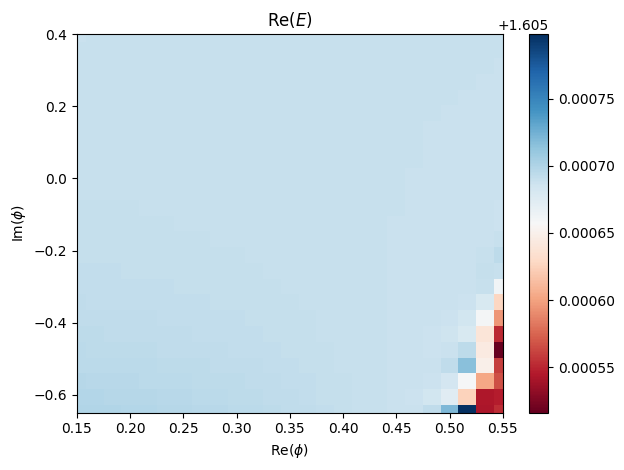

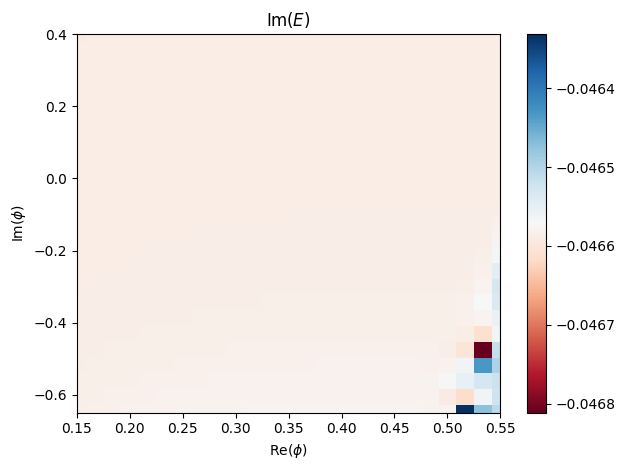

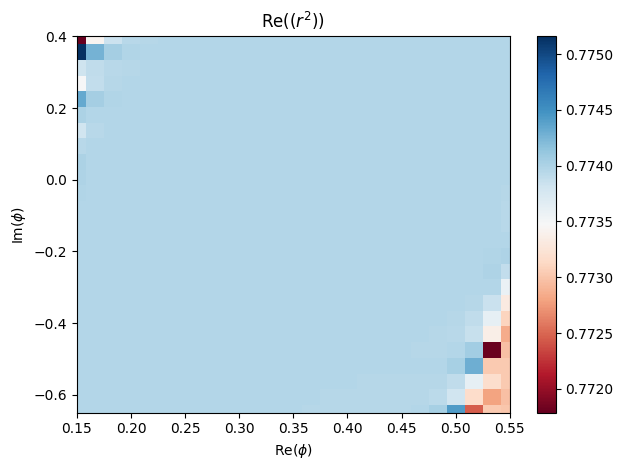

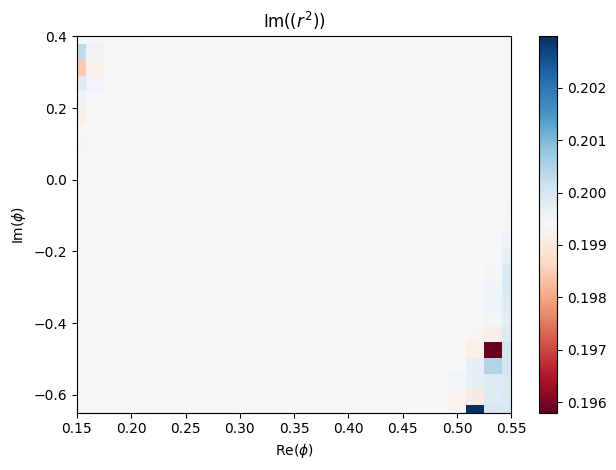

In [10]:
def plot_data_over_complex_theta(
    xv, yv,
    z,
    title="",
    cmap='RdBu'
):
    fig, ax = plt.subplots()
    z_min, z_max = np.min(z), np.max(z)
    c = ax.pcolormesh(xv, yv, z, cmap=cmap, vmin=z_min, vmax=z_max)
    ax.set_title(title)
    ax.axis([xv.min(), xv.max(), yv.min(), yv.max()])
    ax.set_xlabel(r"Re($\phi$)")
    ax.set_ylabel(r"Im($\phi$)")
    fig.colorbar(c, ax=ax)
    plt.tight_layout()
    return fig, ax

# real energy plot
z = np.real(energies)
plot_data_over_complex_theta(xv, yv, z, title=r'Re($E$)')
plt.show()

# imag energy plot
z = np.imag(energies)
plot_data_over_complex_theta(xv, yv, z, title=r'Im($E$)')
plt.show()

# real rr plot
z = np.real(rrs)
plot_data_over_complex_theta(xv, yv, z, title=r'Re($(r^2)$)')
plt.show()

# imag rr plot
z = np.imag(rrs)
plot_data_over_complex_theta(xv, yv, z, title=r'Im($(r^2)$)')
plt.show()

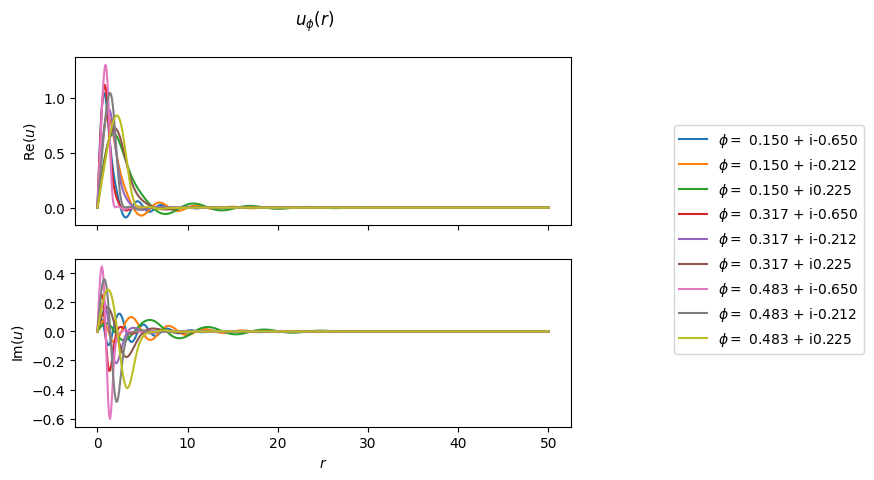

In [11]:
fig, (real_ax, imag_ax) = plt.subplots(2, 1, sharex=True)
skip = 10
for i in range(phi_real_scan)[::skip]:
    for j in range(phi_imag_scan)[::skip]:
        pr = xv[i, j]
        pi = yv[i, j]
        label = rf"$\phi=$ {pr:.3f} + i{pi:.3f}"
        real_ax.plot(x_plot, np.real(states[:, i, j]), label=label)
        imag_ax.plot(x_plot, np.imag(states[:, i, j]), label=label)
imag_ax.set_xlabel(r"$r$")
real_ax.set_ylabel(r"Re($u$)")
imag_ax.set_ylabel(r"Im($u$)")
h, l = real_ax.get_legend_handles_labels()
fig.legend(h, l, loc='center left', bbox_to_anchor=(1.05, .5))
fig.suptitle(r"$u_\phi(r)$")
plt.show()

### Train EC on complex $\theta$.
Here, we train EC on complex $\theta$ and compare the results to those of EC when trained only on real $\theta$. We make sure to account for the added precision expected by adding more training points. The good region of $\phi$ seems to be $\phi\in(0.15, 0.55) + i(-0.65, 0.4)$.

In [14]:
# train on complex rotation angles
dvr_system.reset_rotation_angle(phi_best)
ec_system = ECSystem(dvr_system, real_res)

# get training data
# need sufficiently many on the real portion
phi_lo_real, phi_hi_real, phi_real_scan = 0.15, 0.55, 5
phi_lo_imag, phi_hi_imag, phi_imag_scan = -.65, .4, 5
num_complex_points = phi_imag_scan * phi_real_scan

num_real_points = 25
phi_real_portion = np.linspace(phi_lo_real, phi_hi_real, num_real_points)

num_points = 50

phi_complex_real = np.linspace(phi_lo_real, phi_hi_real, phi_real_scan)
phi_complex_imag = np.linspace(phi_lo_imag, phi_hi_imag, phi_imag_scan)
phi_complex_portion = []
for pr in phi_complex_real:
    for pi in phi_complex_imag:
        phi_complex_portion.append(pr + 1j*pi)
phi_complex_portion = np.asarray(phi_complex_portion, dtype=np.complex128)
phi_train = np.concatenate((phi_real_portion, phi_complex_portion))

ec_system.train(phi_train)
ec_system.construct_basis()

In [15]:
training_vecs = ec_system.training_eigvecs
training_eigs = ec_system.training_eigvals

training_rrs = []
for i, phi in enumerate(phi_train):
    dvr_system.reset_rotation_angle(phi)
    rr = dvr_system.compute_rr(training_vecs[i])
    training_rrs.append(rr)
training_rrs = np.array(training_rrs)

print(f"({np.median(np.real(training_eigs))} + {np.std(np.real(training_eigs))}) "
      f"+ 1j*({np.median(np.imag(training_eigs))} + {np.std(np.imag(training_eigs))})")

print(f"({np.median(np.real(training_rrs))} + {np.std(np.real(training_rrs))}) "
      f"+ 1j*({np.median(np.imag(training_rrs))} + {np.std(np.imag(training_rrs))})")

(1.605689163584076 + 2.315882554598263e-05) + 1j*(-0.046588981051648326 + 1.2341280417180191e-05)
(0.7739628148186035 + 0.00034845828160577294) + 1j*(0.19941123035736966 + 9.255455850917746e-05)


In [16]:
phi_predict = phi_best # np.median(np.real(phi_train)) + 1j*np.median(np.imag(phi_train))
energy, rr = ec_system.predict_energies_rrs([phi_predict])
energy, rr = energy[0], rr[0]
energy_resid = np.real(energy - real_res) / np.real(real_res) + 1j*np.imag(energy - real_res) / np.imag(real_res)
rr_resid = np.real(rr - real_rr) / np.real(real_rr) + 1j*np.imag(rr - real_rr) / np.imag(real_rr)
print(f"Energy prediction: {np.real(energy)} + i{np.imag(energy)}\n"
     f"\tEnergy residual: {energy_resid.real} + i{energy_resid.imag}")
print(f"(r^2): {np.real(rr)} + i{np.imag(rr)}\n"
     f"\t(r^2) residual: {rr_resid.real} + i{rr_resid.imag}")

Energy prediction: 1.6056897826551528 + i-0.046589497719147485
	Energy residual: -1.3535915851185767e-07 + i3.2148174368672134e-05
(r^2): 0.7740000158470363 + i0.19950593137909745
	(r^2) residual: 4.9118492944383954e-05 + i0.0004726472345924648


In [17]:
phi_predict = 0.0 # np.median(np.real(phi_train)) + 1j*np.median(np.imag(phi_train))
energy, rr = ec_system.predict_energies_rrs([phi_predict])
energy, rr = energy[0], rr[0]
energy_resid = np.real(energy - real_res) / np.real(real_res) + 1j*np.imag(energy - real_res) / np.imag(real_res)
rr_resid = np.real(rr - real_rr) / np.real(real_rr) + 1j*np.imag(rr - real_rr) / np.imag(real_rr)
print(f"Energy prediction: {np.real(energy)} + i{np.imag(energy)}\n"
     f"\tEnergy residual: {energy_resid.real} + i{energy_resid.imag}")
print(f"(r^2): {np.real(rr)} + i{np.imag(rr)}\n"
     f"\t(r^2) residual: {rr_resid.real} + i{rr_resid.imag}")

Energy prediction: 1.6056860543300355 + i-0.046594975425223444
	Energy residual: -2.457304937150691e-06 + i0.00014972579255271906
(r^2): 0.7705608725793036 + i0.20109097987958324
	(r^2) residual: -0.00439443722133183 + i0.008421271409895523


In [18]:
# train on purely real rotation angles
dvr_system.reset_rotation_angle(phi_best)
ec_system = ECSystem(dvr_system, real_res)

# get training data
phi_lo_real, phi_hi_real, phi_real_scan = 0.15, 0.55, num_points

phi_train_real = np.linspace(phi_lo_real, phi_hi_real, phi_real_scan)
phi_train = np.asarray(phi_train_real, dtype=np.complex128)

ec_system.train(phi_train)
ec_system.construct_basis()

In [19]:
training_vecs = ec_system.training_eigvecs
training_eigs = ec_system.training_eigvals

training_rrs = []
for i, phi in enumerate(phi_train):
    dvr_system.reset_rotation_angle(phi)
    rr = dvr_system.compute_rr(training_vecs[i])
    training_rrs.append(rr)
training_rrs = np.array(training_rrs)

print(f"({np.median(np.real(training_eigs))} + {np.std(np.real(training_eigs))}) "
      f"+ 1j*({np.median(np.imag(training_eigs))} + {np.std(np.imag(training_eigs))})")

print(f"({np.median(np.real(training_rrs))} + {np.std(np.real(training_rrs))}) "
      f"+ 1j*({np.median(np.imag(training_rrs))} + {np.std(np.imag(training_rrs))})")

(1.605689250257969 + 3.8542318381760334e-07) + 1j*(-0.0465889983350781 + 1.5212911601409812e-07)
(0.7739628337257971 + 3.387923828308644e-06) + 1j*(0.1994112152165296 + 2.1143907034243447e-06)


In [20]:
phi_predict = phi_best # np.median(np.real(phi_train)) + 1j*np.median(np.imag(phi_train))
energy, rr = ec_system.predict_energies_rrs([phi_predict])
energy, rr = energy[0], rr[0]
energy_resid = np.real(energy - real_res) / np.real(real_res) + 1j*np.imag(energy - real_res) / np.imag(real_res)
rr_resid = np.real(rr - real_rr) / np.real(real_rr) + 1j*np.imag(rr - real_rr) / np.imag(real_rr)
print(f"Energy prediction: {np.real(energy)} + i{np.imag(energy)}\n"
     f"\tEnergy residual: {energy_resid.real} + i{energy_resid.imag}")
print(f"(r^2): {np.real(rr)} + i{np.imag(rr)}\n"
     f"\t(r^2) residual: {rr_resid.real} + i{rr_resid.imag}")

Energy prediction: 1.6056897615281116 + i-0.04658947592997735
	Energy residual: -1.4851676753202132e-07 + i3.1680475172852503e-05
(r^2): 0.7740844093488828 + i0.19909355321574368
	(r^2) residual: 0.00015815937847432564 + i-0.0015953267344035638


In [21]:
phi_predict = 0.0 # np.median(np.real(phi_train)) + 1j*np.median(np.imag(phi_train))
energy, rr = ec_system.predict_energies_rrs([phi_predict])
energy, rr = energy[0], rr[0]
energy_resid = np.real(energy - real_res) / np.real(real_res) + 1j*np.imag(energy - real_res) / np.imag(real_res)
rr_resid = np.real(rr - real_rr) / np.real(real_rr) + 1j*np.imag(rr - real_rr) / np.imag(real_rr)
print(f"Energy prediction: {np.real(energy)} + i{np.imag(energy)}\n"
     f"\tEnergy residual: {energy_resid.real} + i{energy_resid.imag}")
print(f"(r^2): {np.real(rr)} + i{np.imag(rr)}\n"
     f"\t(r^2) residual: {rr_resid.real} + i{rr_resid.imag}")

Energy prediction: 1.6056493065091362 + i-0.04662260992197847
	Energy residual: -2.534330466272171e-05 + i0.0007428934914242011
(r^2): 0.7901044206284614 + i0.18797939646400275
	(r^2) residual: 0.020856864585679123 + i-0.05733005978384647
